### Cellular neighborhood downstream analysis
### Figure 3

In [1]:
import os
import sys
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

from tqdm import tqdm
from itertools import chain



#pip install --ignore-installed --upgrade tensorflow



from scipy import ndimage

from sklearn.manifold import TSNE

import phenograph as pg
from scipy.stats import zscore

from skimage.color import rgb2gray

from matplotlib.patches import Polygon

from skimage import io

from skimage import data
from skimage.filters import threshold_otsu
from skimage.segmentation import clear_border
from skimage.measure import label, regionprops
from skimage.morphology import closing, square
from skimage.color import label2rgb
from skimage.io import imread, imshow, imread_collection, concatenate_images
from skimage.transform import resize
from skimage.morphology import label

import seaborn as sns

import scipy.spatial

from scipy.spatial import ConvexHull, convex_hull_plot_2d



from scipy.spatial import distance


import seaborn as sns
from statannot import add_stat_annotation

import matplotlib.image as mpimg 
import time as time

import matplotlib.colors as colors 

from matplotlib import colors as mcolors

colors = dict(mcolors.BASE_COLORS, **mcolors.CSS4_COLORS)

In [2]:
by_hsv = sorted((tuple(mcolors.rgb_to_hsv(mcolors.to_rgba(color)[:3])), name) 
                for name, color in colors.items())
sorted_names = [name for hsv, name in by_hsv]

In [3]:
path_python = './CN_data/CN_matrices/'
path_data = './CN_data/CN_matrices/'
categ = 'all' #'sd_on'#'combined'

colours=[ "lightpink","thistle",
            "palevioletred","mediumorchid","magenta","deeppink"]

colours_1 = ["firebrick","gold","royalblue","green","dimgray","orchid","darkviolet"]

colours_30 = ["firebrick","gold","royalblue","green","dimgray","orchid","darkviolet",
              "red", "orange", "limegreen", "blue", "purple", "seagreen","gold","darkolivegreen",
              "lightpink","thistle","mistyrose","saddlebrown","slategrey","powderblue",
            "palevioletred","mediumvioletred","yellowgreen","lemonchiffon","chocolate",
              "lightsalmon","lightcyan","lightblue", "darkorange"]


colours_33 = ["firebrick","gold","royalblue","green","dimgray","orchid","darkviolet",
              "red", "orange", "limegreen", "blue", "purple", "seagreen","gold","darkolivegreen",
              "lightpink","thistle","mistyrose","saddlebrown","slategrey","powderblue",
            "palevioletred","mediumvioletred","yellowgreen","lemonchiffon","chocolate",
              "lightsalmon","lightcyan","lightblue", "darkorange","black","darkblue","darkgreen"]

path_fig = './CN_figures/'

dpi_set = 100

num_colour = 30
cm = plt.cm.get_cmap('tab20', num_colour)

num_comp = 8

count = 0

pat_num = []

/var/folders/0q/x4j93sjs6mx6sl32x798tmt8001p75/T/ipykernel_7914/2664621668.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('tab20', num_colour)


In [4]:
### roi neighbourhood calculation
from scipy.spatial import distance

from sklearn.metrics.pairwise import euclidean_distances

In [5]:
NSCLC_CM_FOV = []
NSCLC_CM_list = []
cells_per_FOV = []
cent_per_FOV = []
stitched_image_list = []
label_im_st_list = []
X_2d_list = []

In [6]:
count = 0

data_CM = np.zeros((1,7)) #will have all the Count matrices consolidated

num_cells_categ = []  
for fname in os.listdir(path_data):  
    print('reading file '+ str(count))
    print(fname)
    if fname!='.DS_Store':
        if fname!='.ipynb_checkpoints':  #added Aug 18th 2025!!!
    #im = io.imread(fname)
            im = np.array(pd.read_csv(os.path.join(path_data + fname),header=None))#,plugin='matplotlib')
            print (im.shape)
            num_cells_categ.append(im.shape[0])
            count = count + 1
            data_CM = np.concatenate((data_CM,im),axis=0)

reading file 0
data_CM_pd_on.csv
(21293, 7)
reading file 1
.DS_Store
reading file 1
data_CM_pd_pre.csv
(21160, 7)
reading file 2
data_CM_sd_on.csv
(35871, 7)
reading file 3
.ipynb_checkpoints
reading file 3
data_CM_sd_pre.csv
(43536, 7)


In [7]:
num_cells_categ

[21293, 21160, 35871, 43536]

In [8]:
data_CM.shape

(121861, 7)

In [9]:
label_categ=['PD on','PD pre','SD on', 'SD pre']

In [10]:
a=np.repeat( 3, num_cells_categ[0])#,
b = np.repeat(2, num_cells_categ[1])
c = np.repeat(1,num_cells_categ[2])
d = np.repeat(0, num_cells_categ[3])

In [11]:
ss= np.concatenate([a,b,c,d])

In [12]:
ss.shape

(121860,)

In [13]:
np.repeat( 0, num_cells_categ[0])

array([0, 0, 0, ..., 0, 0, 0])

In [14]:
data_CM = np.delete(data_CM, (0), axis=0)

#remove rows that have 0 rowsum

row_sums_CM = data_CM.sum(axis=1,keepdims=True)
rows_remove = np.where(row_sums_CM==0)
data_CM = np.delete(data_CM,(rows_remove),axis=0)

In [15]:
rows_remove

(array([], dtype=int64), array([], dtype=int64))

In [16]:
##stop, running repeat? then 2d coordinates are avl.

M =  data_CM #zscore(data_CM,axis=1)

M_upd = M

num_cells = M.shape[0]
num_genes = M.shape[1]

## uncomment to run the t-SNE
#tsne = TSNE(n_components=2, verbose=1)#, perplexity=30, n_iter=900)
#X_2d = tsne.fit_transform(M_upd)
## save the tSNE coordinates
#df_data = pd.DataFrame(X_2d)
#df_data.to_csv(os.path.join(path_python + categ+'/X2d_M_fovall_CM_spat_'+categ+'.csv'), header=None, index=None)


In [17]:
##if tsne is not run in this session, preload the tSNE file saved from previous session

df_Xtsne = pd.read_csv(os.path.join('./CN_data/X2d_M_fovall_CM_spat_combined.csv'), index_col=None, header= None)
df_Xtsne.shape
X_2d = np.array(df_Xtsne )

In [18]:
### uncomment if clustering in this session
### use HPC
#communities, graph, Q = pg.cluster(M, min_cluster_size=1,k=150)
#cluster_asgn = communities
#df_data_clus = pd.DataFrame(cluster_asgn)
#df_data_clus.to_csv(os.path.join(path_python + categ+'/cluster_asgnments_CM_spat'+categ+'.csv'), header=None, index=None)


In [19]:
##if clustering is not run in this session, preload the clustering file saved from previous session
df_cluster_asgn = pd.read_csv(os.path.join( './CN_data/cluster_asgnments_CM_spatcombined.csv'), index_col=None, header= None)
df_cluster_asgn.shape
cluster_asgn = np.array(df_cluster_asgn ).flatten()

unique [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]


Text(0.5, 1.0, 'CN t-SNE')

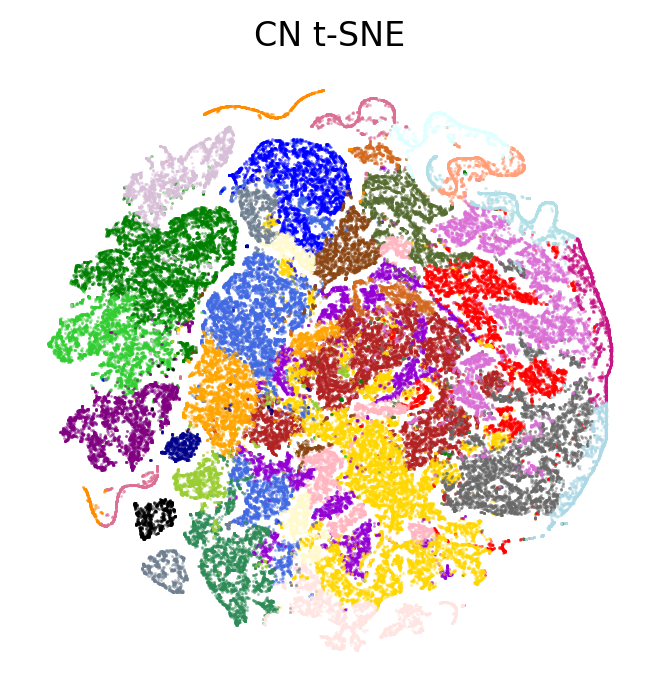

In [20]:
## Fig 3C with 'all'clusters pre merge

unique, counts = np.unique(cluster_asgn, return_counts=True)
print('unique',str(unique))

#t-SNE plots
target_ids = range(len(unique))
plt.figure(figsize=(4,4),dpi=200)
plt.axis('off')



for i,  label in zip(target_ids,  unique):

        c = colours_33[i]#cm.colors[i+1]
       
        plt.scatter(X_2d[ cluster_asgn==(i), 0], X_2d[ cluster_asgn==(i), 1], color=c,label=label,s=1,linewidths=0,alpha=0.5)
    
        
#plt.legend()
plt.title('CN t-SNE')
#plt.show()

#file_name = os.path.join(path_fig + '/cluster_asgnments_tSNE_labels.png')
#plt.savefig(file_name,dpi=dpi_set)

In [21]:
print(unique)
print(counts)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]
[12008 10443  9059  8144  6835  6515  6371  5406  4659  4475  4152  4056
  3657  3472  3074  2958  2806  2662  2535  1931  1787  1698  1661  1630
  1566  1537  1379  1253  1229  1031  1027   844]


In [22]:
num_cells_categ

[21293, 21160, 35871, 43536]

0
0
(array([ 78324,  78325,  78326, ..., 121857, 121858, 121859]),)
1
1
(array([42453, 42454, 42455, ..., 78321, 78322, 78323]),)
2
2
(array([21293, 21294, 21295, ..., 42450, 42451, 42452]),)
3
3
(array([    0,     1,     2, ..., 21290, 21291, 21292]),)


/var/folders/0q/x4j93sjs6mx6sl32x798tmt8001p75/T/ipykernel_7914/1312474093.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('tab20', num_colour)


Text(0.5, 1.0, 't-SNE')

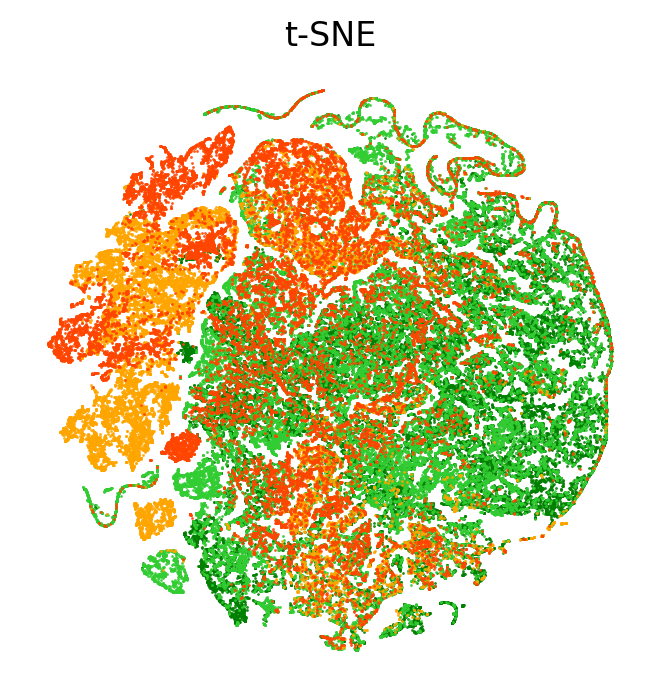

In [23]:
## Fig 3Cii
plt.figure(figsize=(4,4),dpi=200)

unique_c, counts_c = np.unique(ss, return_counts=True)

num_colour = 10#len(unique_c)
cm = plt.cm.get_cmap('tab20', num_colour)

#t-SNE plots
target_ids_c = range(len(unique_c))

plt.axis('off')

cco = ['green','limegreen','orange','orangered']

for i,  label in zip(target_ids_c,  unique_c):
    print(label)
    print(i)
    c=cco[i]#cm.colors[i+1]
    s =  np.where(np.array(ss)==unique_c[i])
    print(s)
    plt.scatter(X_2d[ s, 0], X_2d[ s, 1], color=c,label=label_categ[label],s=1,linewidths=0,alpha=0.9)

#plt.legend(loc=1,fontsize='small')
plt.title('t-SNE')
#plt.show()

#file_name = os.path.join(path_fig +'/pat_response_asgnments_tSNE.png')
#plt.savefig(file_name,dpi=dpi_set)


In [24]:
data_CM.shape

(121860, 7)

#### generate overall heatmap

In [118]:
y_marker = ['CD3', 'PD1', 'CD8', 'PDL1', 'FoxP3', 'PanCK', 'DAPI']


print('Postprocessing the Count matrix results')
####post processing

## plot heatmaps and clustermaps

cluster_stats = np.zeros([len(target_ids),7], dtype=float)
yticks = np.array(target_ids)
for k in target_ids:
    #print(k)
    yticks[k] = int(k)
    cell_rows = np.array(np.where(cluster_asgn == (k))).flatten()
    cluster_stats[k,:] = data_CM[cell_rows,:].sum(axis=0,keepdims=True)



Postprocessing the Count matrix results


In [117]:
#heatmap2
plt.figure(3000 ,dpi=dpi_set,figsize=(8,8))
dd = zscore(np.transpose(cluster_stats),axis=1)
mask = np.full_like(dd, False)#, dtype=bool)
mask[6,:] = True
hm= sns.heatmap(dd, mask = mask,  cmap='coolwarm',robust='True',xticklabels=yticks,yticklabels=y_marker[0:6], vmin = -1, vmax = 1)
plt.close()


#### merge clusters + CN heatmap

In [55]:
cluster_asgn1 = np.copy(cluster_asgn)

In [56]:
cluster_asgn2 = np.zeros(cluster_asgn1.shape)

In [57]:
## combining clusters based on similar marker profile

## pd1/cd3/8/fox
row = np.where(cluster_asgn1==30)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==3)
cluster_asgn2[row]=np.int64(100)

#pd1

row = np.where(cluster_asgn1==7)
cluster_asgn2[row]=np.int64(200)
row = np.where(cluster_asgn1==21)
cluster_asgn2[row]=np.int64(200)
row = np.where(cluster_asgn1==22)
cluster_asgn2[row]=np.int64(200)
row = np.where(cluster_asgn1==20)
cluster_asgn2[row]=np.int64(200)
row = np.where(cluster_asgn1==29)
cluster_asgn2[row]=np.int64(200)


#panck
row = np.where(cluster_asgn1==10)
cluster_asgn2[row]=np.int64(300)
row = np.where(cluster_asgn1==19)
cluster_asgn2[row]=np.int64(300)
row = np.where(cluster_asgn1==13)
cluster_asgn2[row]=np.int64(300)
row = np.where(cluster_asgn1==17)
cluster_asgn2[row]=np.int64(300)


#pdl1 panck

row = np.where(cluster_asgn1==2)
cluster_asgn2[row]=np.int64(400)
row = np.where(cluster_asgn1==6)
cluster_asgn2[row]=np.int64(400)

row = np.where(cluster_asgn1==12)
cluster_asgn2[row]=np.int64(400)

#pdl1 cd3/ 8 panck
row = np.where(cluster_asgn1==1)
cluster_asgn2[row]=np.int64(500)

#fox pd1 panck
row = np.where(cluster_asgn1==11)
cluster_asgn2[row]=np.int64(600)
row = np.where(cluster_asgn1==14)
cluster_asgn2[row]=np.int64(600)
row = np.where(cluster_asgn1==15)
cluster_asgn2[row]=np.int64(600)
row = np.where(cluster_asgn1==18)
cluster_asgn2[row]=np.int64(600)
row = np.where(cluster_asgn1==24)
cluster_asgn2[row]=np.int64(600)
row = np.where(cluster_asgn1==25)
cluster_asgn2[row]=np.int64(600)
row = np.where(cluster_asgn1==26)
cluster_asgn2[row]=np.int64(600)
row = np.where(cluster_asgn1==27)
cluster_asgn2[row]=np.int64(600)
row = np.where(cluster_asgn1==28)
cluster_asgn2[row]=np.int64(600)

#cd3 cd8 pdl1
row = np.where(cluster_asgn1==0)
cluster_asgn2[row]=np.int64(700)

#cd3 cd8 pdl1 pd1
row = np.where(cluster_asgn1==16)
cluster_asgn2[row]=np.int64(800)

#cd3 cd8 
row = np.where(cluster_asgn1==4)
cluster_asgn2[row]=np.int64(900)
row = np.where(cluster_asgn1==5)
cluster_asgn2[row]=np.int64(900)

#pdl1
row = np.where(cluster_asgn1==8)
cluster_asgn2[row]=np.int64(1000)


#pd1 panck
row = np.where(cluster_asgn1==9)
cluster_asgn2[row]=np.int64(1100)

#fox cdd8 pdl1
row = np.where(cluster_asgn1==31)
cluster_asgn2[row]=np.int64(1200)
row = np.where(cluster_asgn1==23)
cluster_asgn2[row]=np.int64(1200)


cluster_asgn2 = cluster_asgn2 -1

In [58]:
cluster_asgn2 = np.int64(cluster_asgn2/100)

In [59]:
np.max(cluster_asgn2)

11

unique [ 0  1  2  3  4  5  6  7  8  9 10 11]


Text(0.5, 1.0, 'CN t-SNE')

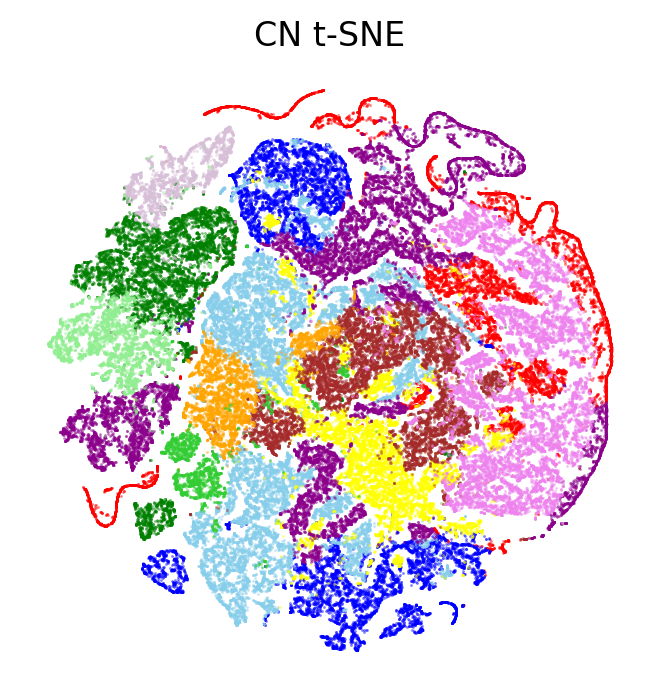

In [60]:
## Fig 3C

unique, counts = np.unique(cluster_asgn2, return_counts=True)
print('unique',str(unique))

#t-SNE plots
target_ids = range(len(unique))
plt.figure(figsize=(4,4),dpi=200)
plt.axis('off')
#previous
#cc = ['green','red','blue','skyblue','yellow','darkmagenta','brown','thistle','violet','orange','lightgreen','grey']
#new
cc = ['green','red','blue','skyblue','yellow','darkmagenta','brown','thistle','violet','orange','lightgreen','limegreen']
for i,  label in zip(target_ids,  unique):

    c=cc[i] 
    plt.scatter(X_2d[ cluster_asgn2==(i), 0], X_2d[ cluster_asgn2==(i), 1], color=c,label=label,s=1,linewidths=0,alpha=0.5)
#plt.legend()
plt.title('CN t-SNE')
#plt.show()

#file_name = os.path.join(path_fig + '/cluster_asgnments_tSNE_labels.png')
#plt.savefig(file_name,dpi=dpi_set)

In [61]:
unique_c2, counts_c2 = np.unique(cluster_asgn2, return_counts=True)

target_ids_c2 = range(len(unique_c2))

In [62]:
# generate the cluster stats

cluster_stats_1 = np.copy(cluster_stats[:,0:6]) 
cluster_stats_merge = np.copy(cluster_stats_1)
cluster_stats_merge_1 = np.copy(cluster_stats_1)


clust_temp_1 = np.array((cluster_stats_merge[10,:]+cluster_stats_merge[19,:]+cluster_stats_merge[13,:]+cluster_stats_merge[17,:])/4)
clust_temp_2 = np.array((cluster_stats_merge[2,:]+ cluster_stats_merge[6,:]+cluster_stats_merge[12,:])/3)

clust_temp_3 = np.array((cluster_stats_merge[4,:]+cluster_stats_merge[5,:])/2)
clust_temp_4 = np.array((cluster_stats_merge[23,:]+cluster_stats_merge[31,:])/2)
clust_temp_5 = np.array((cluster_stats_merge[3,:]+cluster_stats_merge[30,:])/2)

clust_temp_6 = np.array((cluster_stats_merge[7,:]+cluster_stats_merge[20,:]+cluster_stats_merge[21,:]+
                       cluster_stats_merge[22,:]+
                       cluster_stats_merge[29,:])/5)


clust_temp_7 =np.array((cluster_stats_merge[11,:]+
                       cluster_stats_merge[14,:]+cluster_stats_merge[15,:]+
                        cluster_stats_merge[18,:]+cluster_stats_merge[24,:]+
                        cluster_stats_merge[25,:]+cluster_stats_merge[26,:]+
                        cluster_stats_merge[27,:]+cluster_stats_merge[28,:])/9)    

In [63]:
# update the cluster stats matrix

cluster_stats_merge_1[0,:]=clust_temp_5
cluster_stats_merge_1[1,:]=clust_temp_6
cluster_stats_merge_1[2,:]=clust_temp_1
cluster_stats_merge_1[3,:]=clust_temp_2
cluster_stats_merge_1[4,:]=cluster_stats_merge[1,:]
cluster_stats_merge_1[5,:]=clust_temp_7 
cluster_stats_merge_1[6,:]=cluster_stats_merge[0,:]
cluster_stats_merge_1[7,:]=cluster_stats_merge[16,:]
cluster_stats_merge_1[8,:]=clust_temp_3 
cluster_stats_merge_1[9,:]=cluster_stats_merge[8,:]
cluster_stats_merge_1[10,:]=cluster_stats_merge[9,:]
cluster_stats_merge_1[11,:]=clust_temp_4 


In [64]:
cluster_stats_merge_1[0:12,:].shape

(12, 6)

Text(0.5, 1.0, 'Euclidean distance')

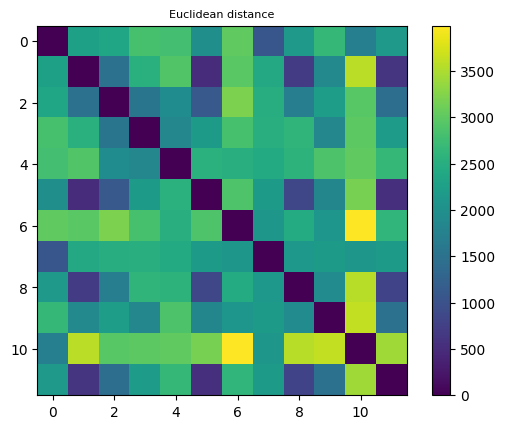

In [122]:
ss_select_inteclusters= euclidean_distances(cluster_stats_merge_1[0:12,:],cluster_stats_merge_1[0:12,:])
plt.imshow(ss_select_inteclusters)
plt.colorbar()
plt.title('Euclidean distance', fontsize=8)

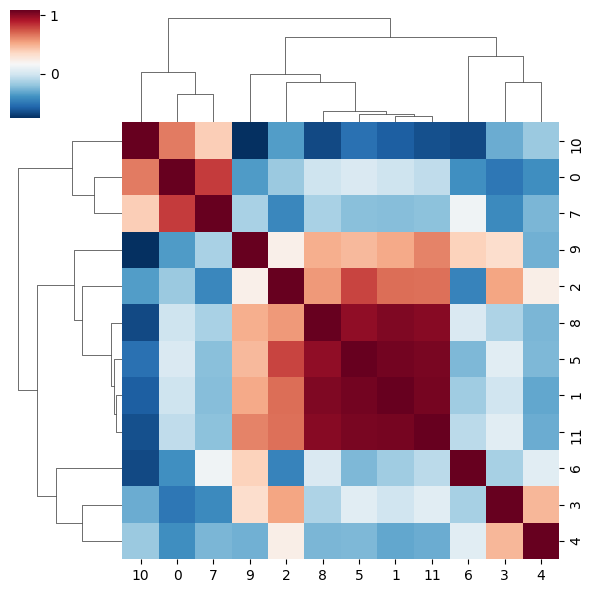

In [123]:
# Clustermap rendering
sns.clustermap(np.cov(zscore(ss_select_inteclusters,axis=1)),cmap='RdBu_r',xticklabels=range(0,12),yticklabels=range(0,12), figsize=(6,6))#, vmin=-1, vmax=1) #coolwarm

#### response heterogeneity

In [67]:
unique_ts, counts_ts = np.unique(ss, return_counts=True)
print(unique_ts.shape[0])

unique_12, counts_12 = np.unique(cluster_asgn2, return_counts=True)
print(unique_12.shape[0])
print(counts_12)


4
12
[ 9171 11583 12217 19087 10443 19587 12008  2806 13350  4659  4475  2474]


In [69]:
# 19 response
#PR = 0, SD =2, PD=1
#label_categ=['PD on' = 3,'PD pre = 2','SD on = 1', 'SD pre'= 0]
pdo_list_n = []
pdpre_list_n = []
sdo_list_n = []
sdpre_list_n = []

pd_list_n = []
sd_list_n = []

tot_cells = ss.shape[0]

pd_list_n = []
sd_list_n = []

# get the rows for sd, pd, pr
unique_ts, counts_ts = np.unique(ss, return_counts=True)
print(unique_ts)
pdo = np.array(np.where(ss==unique_ts[3])).flatten()
pdpre = np.array(np.where(ss==unique_ts[2])).flatten()
sdo = np.array(np.where(ss==unique_ts[1])).flatten()
sdpre = np.array(np.where(ss==unique_ts[0])).flatten()


for l in range(unique_12.shape[0]): #do for each cluster
    f_rows = np.array(np.where(np.array(cluster_asgn2==l))).flatten()
    pdo_f = np.intersect1d(pdo,f_rows)
    pdo_list_n.append(pdo_f.shape[0]*100/pdo.shape[0])  ##check normalization
    #pd_list_n.append(pdo_f.shape[0]*100/pdo.shape[0])  ##check normalization
    
    pdpre_f = np.intersect1d(pdpre,f_rows)
    pdpre_list_n.append(pdpre_f.shape[0]*100/pdpre.shape[0])
    pd_list_n.append(np.mean([pdpre_f.shape[0]*100/pdpre.shape[0],pdo_f.shape[0]*100/pdo.shape[0]]))
    
    sdo_f = np.intersect1d(sdo,f_rows)
    sdo_list_n.append(sdo_f.shape[0]*100/sdo.shape[0])
    #sd_list_n.append(sdo_f.shape[0]*100/sdo.shape[0])  ##check normalization
    
    sdpre_f = np.intersect1d(sdpre,f_rows)
    sdpre_list_n.append(sdpre_f.shape[0]*100/sdpre.shape[0])
    sd_list_n.append(np.mean([sdpre_f.shape[0]*100/sdpre.shape[0],sdo_f.shape[0]*100/sdo.shape[0]]))
    





[0 1 2 3]


In [71]:
cell_classes = [
'CD3+CD8+FoXP3+PD-1+',
'PD-1+',
'PanCK+',
'PD-L1+PanCK+',
'CD3+CD8+PD-L1+PanCK+',
'FoXP3+PD-1+PanCK+',
'CD3+CD8+PD-L1+',
'CD3+CD8+PD-L1+PD-1+',
'CD3+CD8+',
'PD-L1+',
'PD-1+PanCK+',
'FoxP3+CD8+PD-L1+']


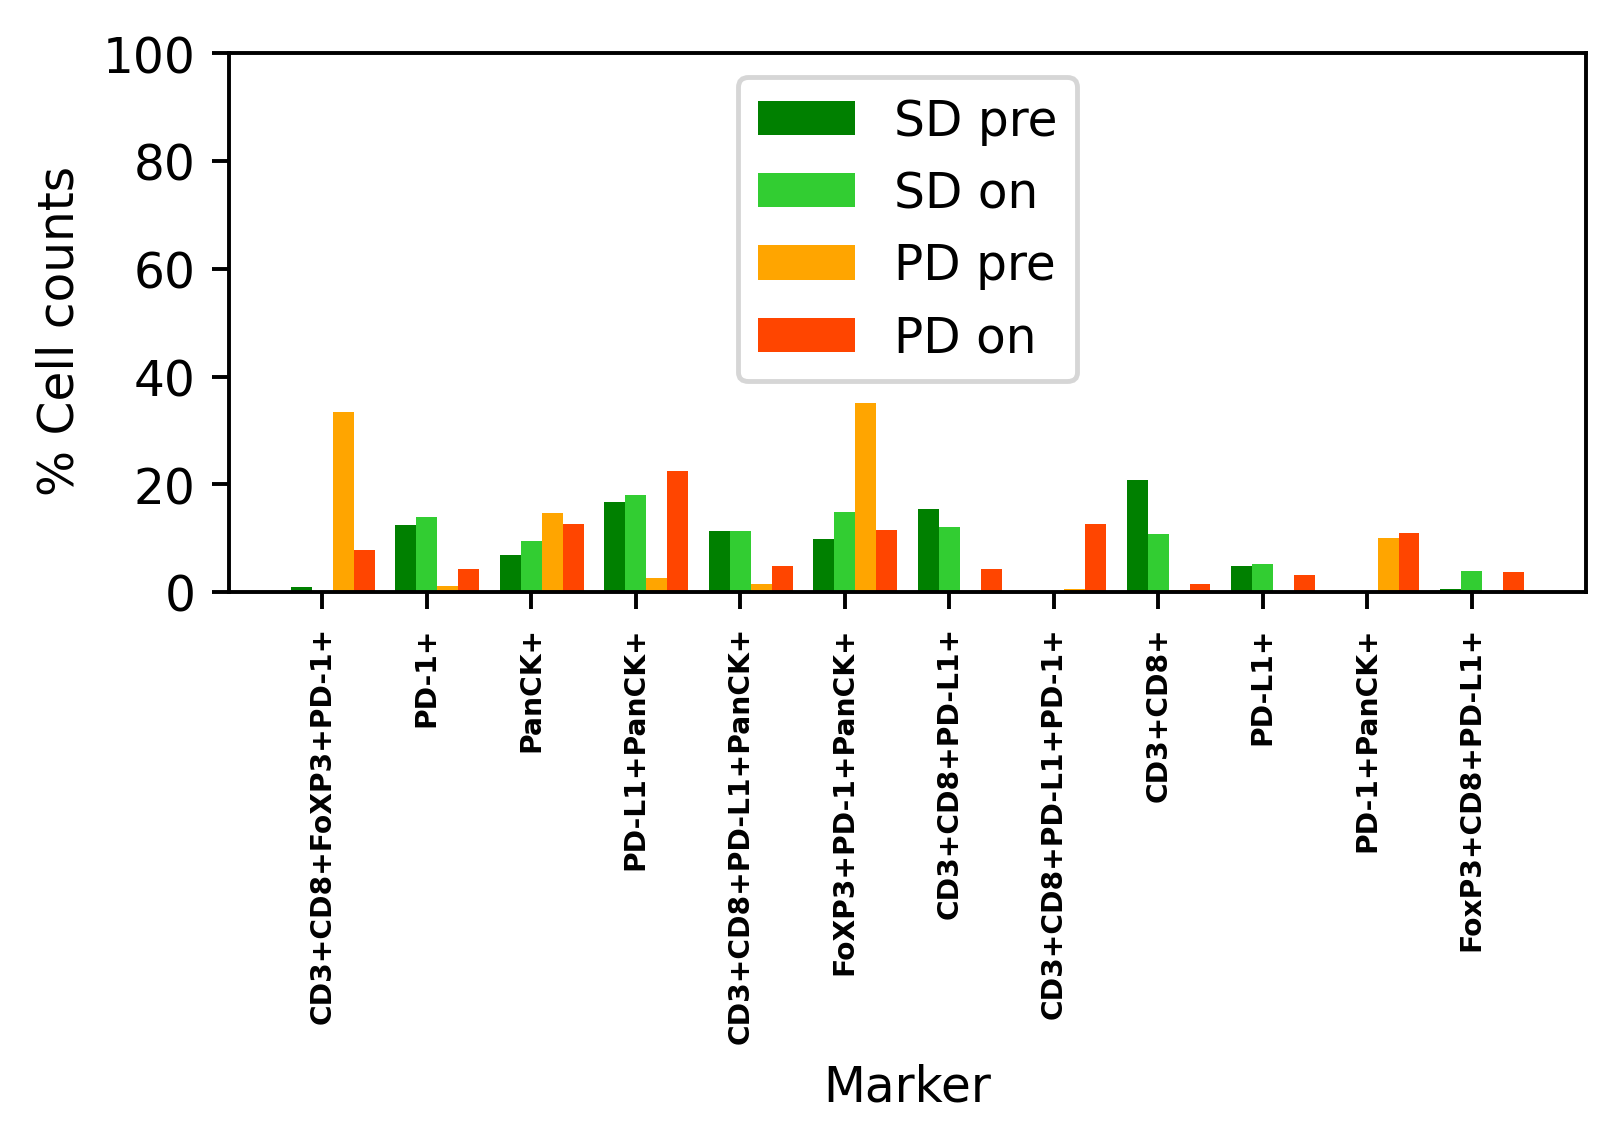

In [80]:
## 
plt.figure(figsize=(5,2), dpi=350)
# create data 
x = np.arange(12) 
y4 = pdo_list_n
y3 = pdpre_list_n
y2 = sdo_list_n
y1 = sdpre_list_n
width = 0.2
  

# plot data in grouped manner of bar type 
plt.bar(x-0.2, y1, width, color='green') 
plt.bar(x, y2, width, color='limegreen') 
plt.bar(x+0.2, y3, width, color='orange') 
plt.bar(x+0.4, y4, width, color='orangered') # shades 
plt.xticks(x, cell_classes,rotation=90,fontsize='xx-small',fontweight='bold')  
plt.xlabel("Marker") 
plt.ylabel("% Cell counts ")#/ Cellular Neighborhood Counts of cells (%)") 
plt.legend(["SD pre","SD on", "PD pre", "PD on"], loc=9) 
plt.ylim(0,100)
plt.show() 

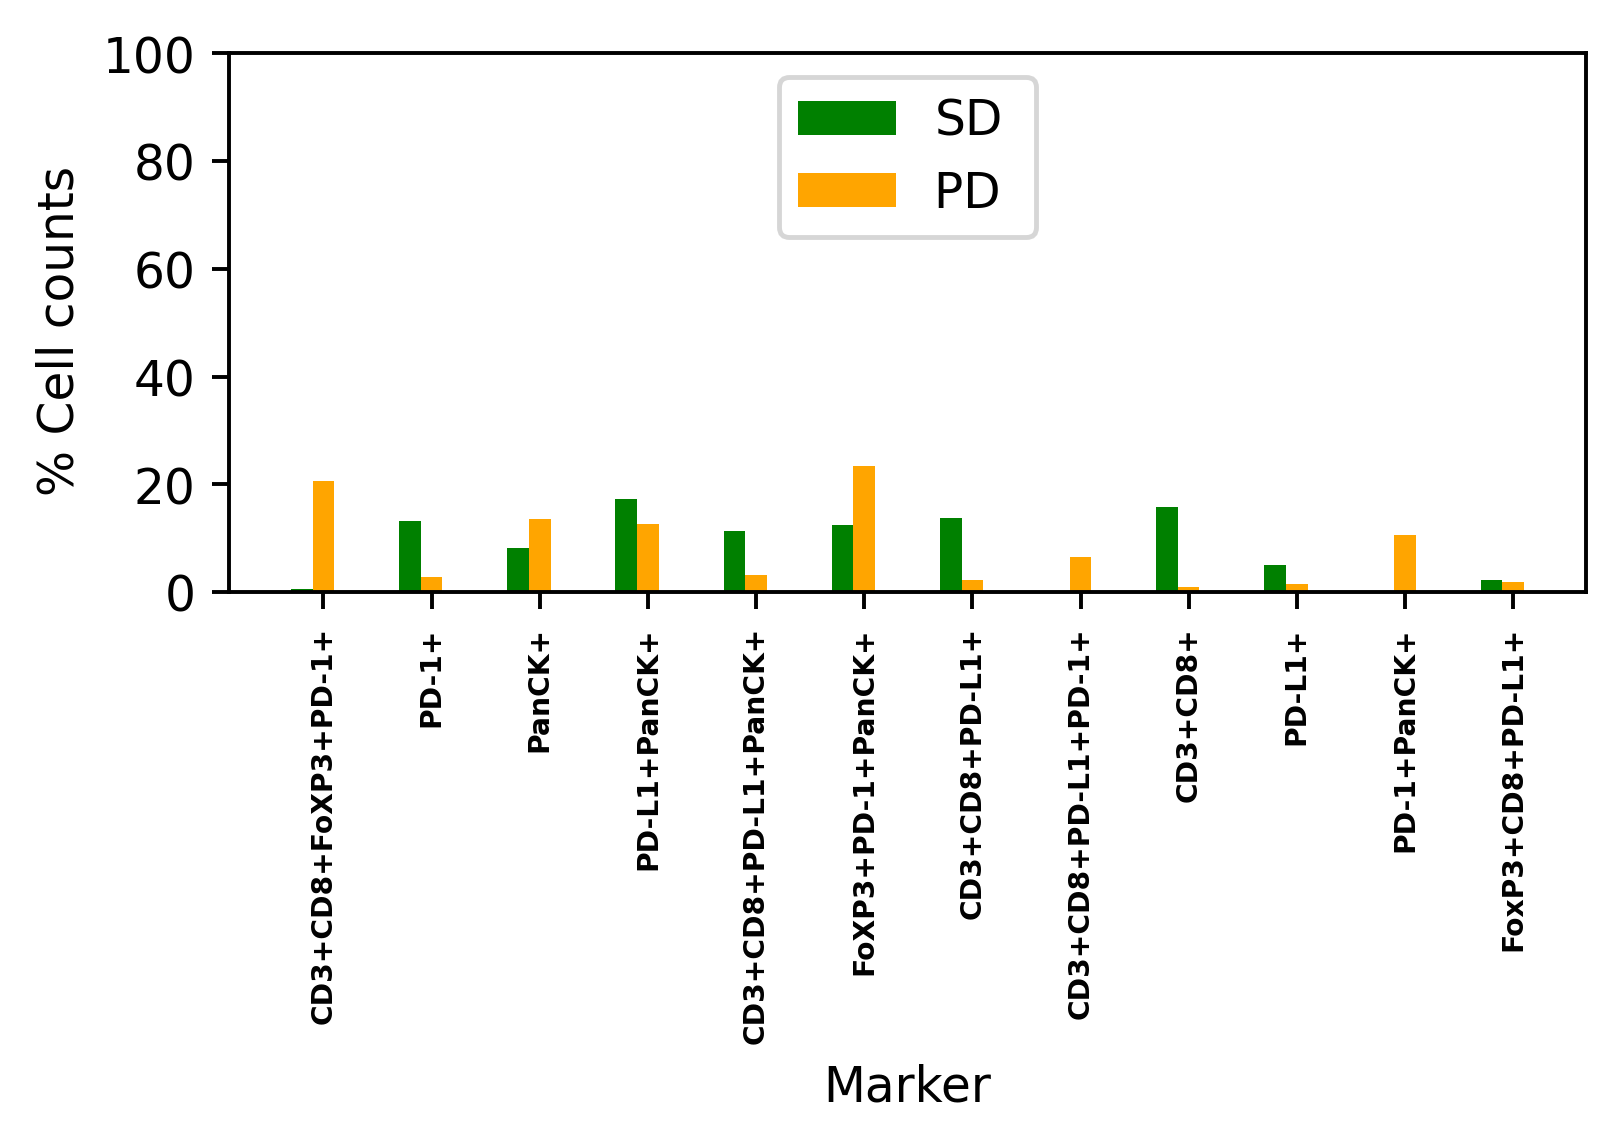

In [82]:
## 

plt.figure(figsize=(5,2), dpi=350)
# create data 
x = np.arange(12) 
y2 = pd_list_n
y1 = sd_list_n
width = 0.2
  
# plot data in grouped manner of bar type 
plt.bar(x-0.2, y1, width, color='green') 
plt.bar(x, y2, width, color='orange') 
#plt.bar(x+0.2, y3, width, color='orange') 
#plt.bar(x+0.4, y4, width, color='orangered') # shades 
plt.xticks(x, cell_classes,rotation=90,fontsize='xx-small', fontweight='bold') 
plt.xlabel("Marker") 
plt.ylabel("% Cell counts ")#/ Cellular Neighborhood Counts of cells (%)") 
plt.legend(["SD", "PD "], loc=9) 
plt.ylim(0,100)
plt.show() 